In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from scipy import stats
import utils
import seaborn as sns
import pingouin as pg
import matplotlib.cm as cm
from matplotlib.patches import Rectangle


import statsmodels.stats.power as smp
from statsmodels.stats.anova import AnovaRM
from tqdm import tqdm


from natsort import index_natsorted

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.family'] = 'Calibri'

path_figs = "./Figs/"

seq_length = 7 #Length of sequences

fingers = ['1', '2', '3', '4', '5'] #mapping of fingers to numbers

iti = 1000 # msecs for inter-trial interval
planTime = 2000 # msecs for precue time
feedbackTime = 2000 # msecs for feedback time


total_sub_num = 20
num_sessions = 6
num_blocks_per_session = 10
num_trials_per_block = 20

sub_nums = [1,2]

utils.set_figure_style("1col")
sns.color_palette('colorblind')



[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [4]:
# reload utils
import importlib
importlib.reload(utils)

<module 'utils' from '/Users/amin/projects/LearningDynamics/ChordLearningDynamics/utils.py'>

In [5]:
subjs_list = utils.read_dat_files_subjs_list(sub_nums)

subjs = pd.concat(subjs_list, ignore_index=True)

subjs['TotalTrialNum'] = (subjs['BN'] - 1) * num_trials_per_block + subjs['TN']
subjs.reset_index(drop=True, inplace=True)

In [6]:
subjs

,BN,TN,subNum,planTime,feedbackTime,iti,fGain1,fGain2,fGain3,fGain4,...,targetForce5,endForce1,endForce2,endForce3,endForce4,endForce5,trialCorr,trialErrorType,trialPoint,TotalTrialNum
0,1,1,1,2000,2000,1000,1.0,1.0,1.0,1.0,...,-1.0,1.163,-1.294,-0.180,1.030,-0.955,1,0,3.250,1
1,1,2,1,2000,2000,1000,1.0,1.0,1.0,1.0,...,-1.0,2.494,-0.679,-1.407,0.977,-1.560,1,0,3.881,2
2,1,3,1,2000,2000,1000,1.0,1.0,1.0,1.0,...,-1.0,2.370,-1.605,0.188,0.850,-1.992,0,2,-1.000,3
3,1,4,1,2000,2000,1000,1.0,1.0,1.0,1.0,...,-1.0,1.972,-1.979,0.058,0.978,-2.864,1,0,2.190,4
4,1,5,1,2000,2000,1000,1.0,1.0,1.0,1.0,...,-1.0,2.404,-1.677,0.641,0.836,-1.897,1,0,2.573,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,60,16,2,2000,2000,1000,1.0,1.0,1.0,1.0,...,-1.0,1.579,-1.621,-0.477,1.323,-1.058,1,0,3.582,1196
2396,60,17,2,2000,2000,1000,1.0,1.0,1.0,1.0,...,-1.0,1.778,-1.147,-1.966,1.084,-0.663,1,0,4.663,1197
2397,60,18,2,2000,2000,1000,1.0,1.0,1.0,1.0,...,-1.0,2.316,-3.472,-0.895,1.539,-0.998,1,0,3.201,1198
2398,60,19,2,2000,2000,1000,1.0,1.0,1.0,1.0,...,-1.0,1.466,-1.857,-0.046,1.645,-0.341,1,0,2.881,1199


# Mov Files

In [7]:
import glob
import os
def movload(fname):
    # loads .mov files given the path of the file. The .mov files have a specific custom hence the need for a custom function
    A = []
    fid = open(fname, 'rt')
    if fid == -1:
        raise Exception('Could not open ' + fname)


    num_columns = None 

    trial = 0
    for line in fid:
        if line[0] == 'T':
            # print('Trial: ', line.split()[1])
            a = int(line.split()[1])
            trial += 1
            if a != trial:
                print('Trials out of sequence')
                trial = a
            A.append([])
            num_columns = None
            # A[trial-1] = np.empty((0,8))
        else:
            lineData = line.strip().split('\t')
            if num_columns is None:
                num_columns = len(lineData)
                A[trial - 1] = np.empty((0, num_columns))
            a = np.array([float(x) for x in lineData], ndmin=2)
            # print(a)
            A[trial-1] = np.vstack((A[trial-1],a))
            # A[trial-1].extend(a)

    fid.close()
    return A
pattern = utils.path +  "_*_*.mov"
files = glob.glob(pattern)
dfs = []
for file in files:
    filename = os.path.basename(file)

    parts = filename.split('_')

    if len(parts) >= 5:
        subnum = int(parts[3])
        block_number = int(parts[4].replace('.mov', ''))
        
        if subnum not in sub_nums:
            continue
        print(subnum, block_number)

        trials = movload(file)
        for trial_idx, trial in enumerate(trials):
            df = pd.DataFrame(trial, columns=['state',
                                              'timeReal', 'time',
                                              'ext1', 'ext2', 'ext3', 'ext4', 'ext5', 
                                              'flx1', 'flx2', 'flx3', 'flx4', 'flx5'])
            df['TN'] = trial_idx + 1
            df['BN'] = block_number
            df['subNum'] = subnum
            for finger in fingers:
                df[f'force{finger}'] = np.round(df[f'ext{finger}'] - df[f'flx{finger}'], 2)
            dfs.append(df)
        

dfs = pd.concat(dfs)


subjs_force = dfs.merge(subjs, on = ['subNum' , 'BN', 'TN'], how='inner')[['state', 'time', 'subNum', 
                                                                           'BN','TN', 'trialCorr', 'trialErrorType', 'trialPoint',
                                                                           'targetForce1', 'targetForce2', 'targetForce3', 'targetForce4', 'targetForce5',
                                                                           'endForce1', 'endForce2', 'endForce3', 'endForce4', 'endForce5',
                                                                           'TotalTrialNum'] + [f'force{finger}' for finger in fingers]]

1 39
1 11
1 5
2 40
2 54
2 55
2 41
1 4
1 10
1 38
1 6
1 12
2 57
2 43
2 42
2 56
1 13
1 7
1 3
1 17
2 52
2 46
2 47
2 53
1 16
1 2
1 14
1 28
2 45
2 51
2 50
2 44
1 29
1 1
1 15
2 23
2 37
2 36
2 22
1 59
2 34
2 20
2 8
2 9
2 21
2 35
1 58
1 60
1 48
2 19
2 31
2 25
2 24
2 30
2 18
1 49
2 26
2 32
2 33
2 27
1 53
1 47
2 2
2 16
2 17
2 3
1 46
1 52
1 44
1 50
2 15
2 1
2 29
2 28
2 14
1 51
1 45
1 41
1 55
2 38
2 10
2 4
2 5
2 11
2 39
1 54
1 40
1 56
1 42
2 7
2 13
2 12
2 6
1 43
1 57
1 18
1 30
1 24
2 49
2 48
2 60
1 25
1 31
1 19
1 27
1 33
1 32
1 26
1 22
1 36
1 37
1 23
1 35
1 21
1 9
2 58
2 59
1 8
1 20
1 34


In [96]:
# ## --- plotting time real increments in the data ----

# diffs = []
# # df_filtered = dfs[(dfs['SubNum'] == 1) & (dfs['BN'] == 10) & (dfs['TN'] == 1)]
# for sub, subdata in dfs.groupby(['SubNum']):
#     for block, blockdata in subdata.groupby(['BN']):
#         for trial, trialdata in blockdata.groupby(['TN']):
#             # diffs = np.append(diffs, trialdata['timeReal'].diff())
#             diffs.extend(trialdata['timeReal'].diff().dropna())

# diffs = np.array(diffs)
# # diffs = diffs[(diffs > 0) & (diffs < 100)]
# # print(diffs.shape)
# # print(diffs)
# # print(sorted(diffs)[:10])
# # print(sorted(diffs)[-10:])

# # 95 and 5 percentile
# lower_bound = np.percentile(diffs, 1)
# upper_bound = np.percentile(diffs, 99)
# print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

# diffs = diffs[(diffs > lower_bound) & (diffs < upper_bound)]


# plt.hist(diffs, bins=100)
# # print(sorted(diffs)[-100:])
# # print(sorted(diffs)[:100])
# plt.show()

# # df_filtered = dfs[(dfs['SubNum'] == 1) & (dfs['BN'] == 10) & (dfs['TN'] == 1)]
# for sub, subdata in dfs.groupby(['SubNum']):
#     for block, blockdata in subdata.groupby(['BN']):
#         for trial, trialdata in blockdata.groupby(['TN']):
#             # diffs = np.append(diffs, trialdata['timeReal'].diff())
#             diffs = trialdata['timeReal'].diff()
#             # return index of diffs greater than 10 if any
#             if diffs[diffs > 10].any():
#                 print("****************")
#                 print(f"SubNum: {sub}, BN: {block}, TN: {trial}")
#                 print(trialdata[diffs > 10])
#                 print(diffs[diffs > 10])

In [48]:
import importlib
importlib.reload(utils)

<module 'utils' from '/Users/amin/projects/LearningDynamics/ChordLearningDynamics/utils.py'>

In [8]:
subjs_force_train = utils.finger_melt_Forces(subjs_force)

In [98]:
subjs_force_train.columns

Index(['state', 'time', 'subNum', 'BN', 'TN', 'targetForce1', 'targetForce2',
       'targetForce3', 'targetForce4', 'targetForce5', 'endForce1',
       'endForce2', 'endForce3', 'endForce4', 'endForce5', 'TotalTrialNum',
       'trialPoint', 'trialCorr', 'trialErrorType', 'Force_Number',
       'Force_Value'],
      dtype='object')

In [9]:
def plot_forces(subjs_forces, sub_num, trial_num):
    plt.figure(figsize=(10,3))
    x = subjs_forces[(subjs_forces['subNum'] == sub_num) & (subjs_forces['TotalTrialNum'] == trial_num)]
    
    for i, (force, data) in enumerate(x.groupby('Force_Number')):
        plt.plot(data['time'], data['Force_Value'], label = force,
                 color = sns.color_palette('colorblind')[i], alpha = 0.5)
    
    
    plt.axvline(2400, color = 'black', linestyle = '--', alpha = 0.5) # go cue 
    plt.axvline(2900, color = 'black', linestyle = '--', alpha = 0.5) # sampling time


    target_cols = [f"targetForce{finger}" for finger in fingers]
    target_vals = x[target_cols].iloc[0].to_numpy(dtype=float)


    ax = plt.gca()

    rec_height = 0.5
    for finger in fingers:
        ax.add_patch(Rectangle((2900 - 95, target_vals[int(finger)-1]- (rec_height/2)), 
                            180, rec_height, color = sns.color_palette('colorblind')[int(finger)-1],alpha=0.5))


    plt.title(f'Subject {sub_num}, Trial {trial_num}')
    plt.legend()
    sns.despine(trim = True)

    plt.show()
    

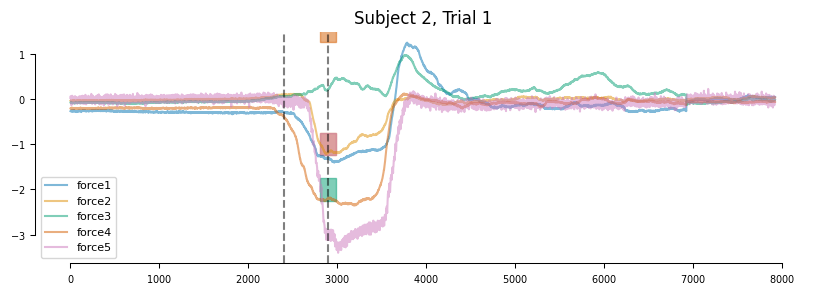

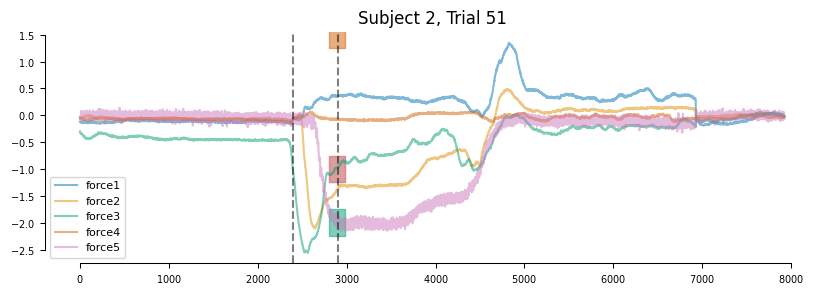

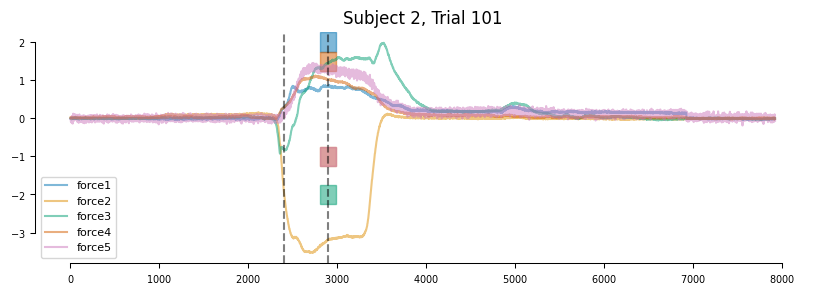

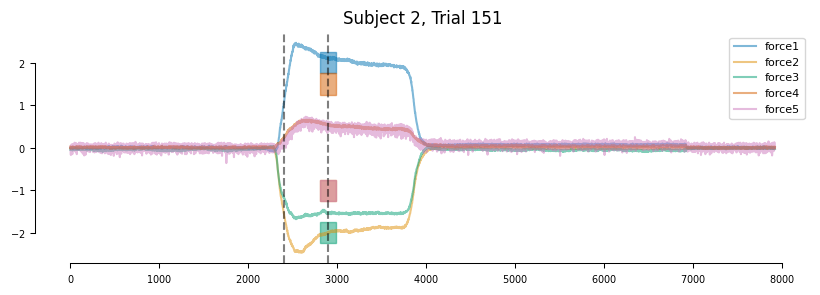

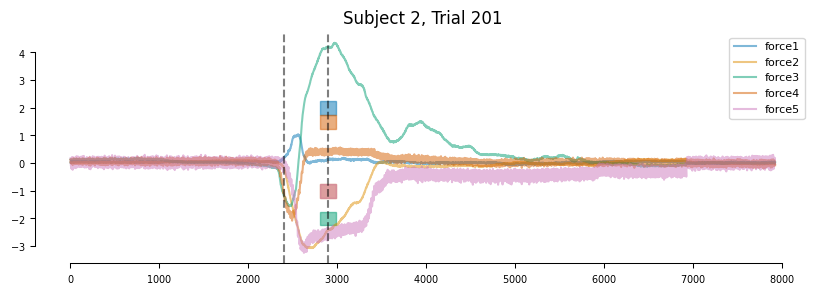

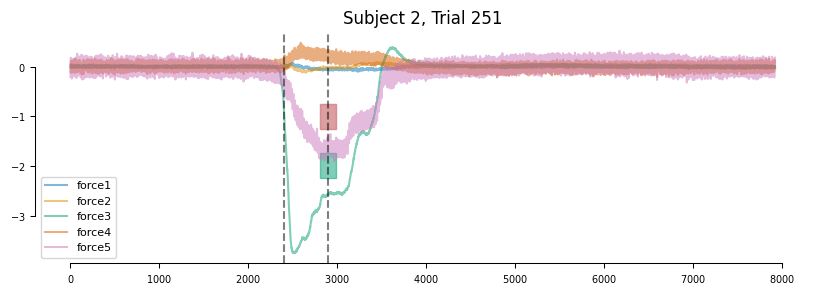

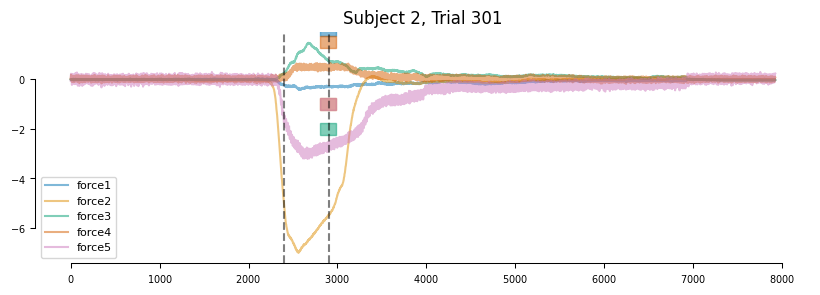

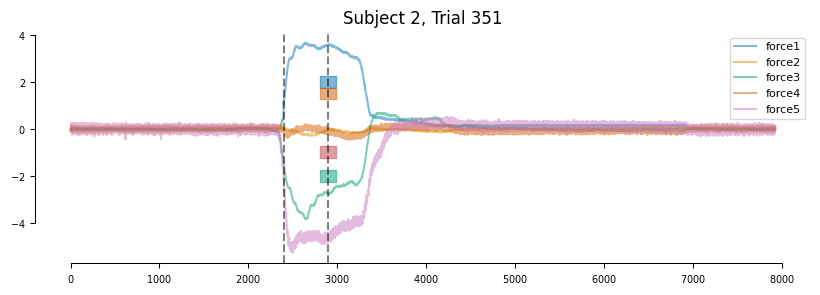

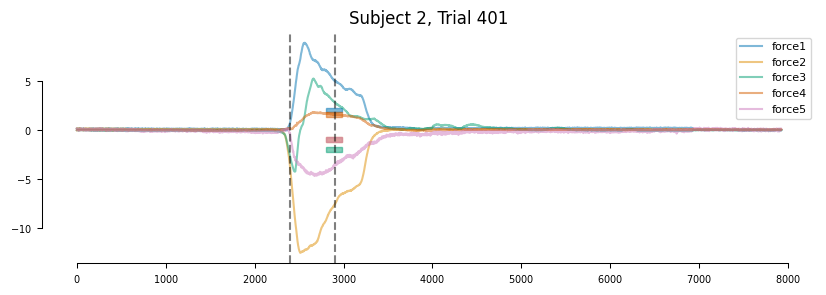

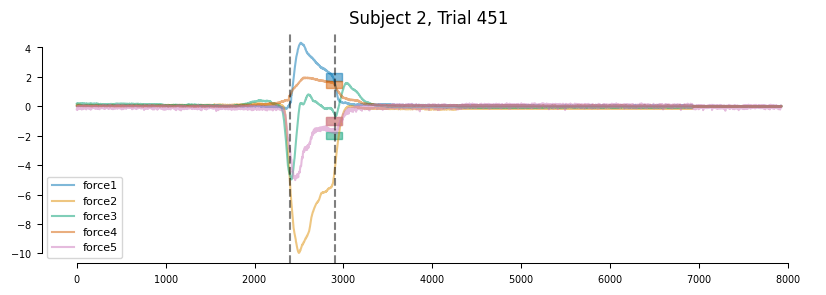

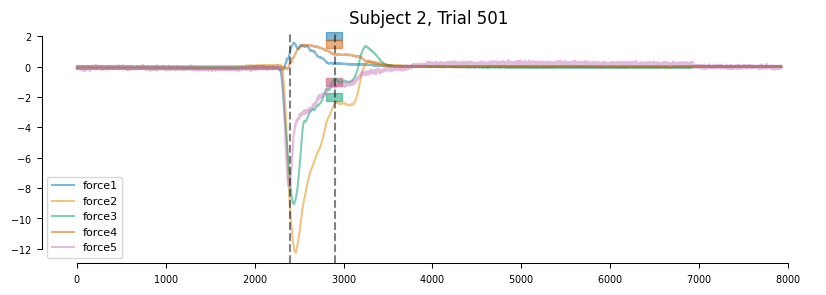

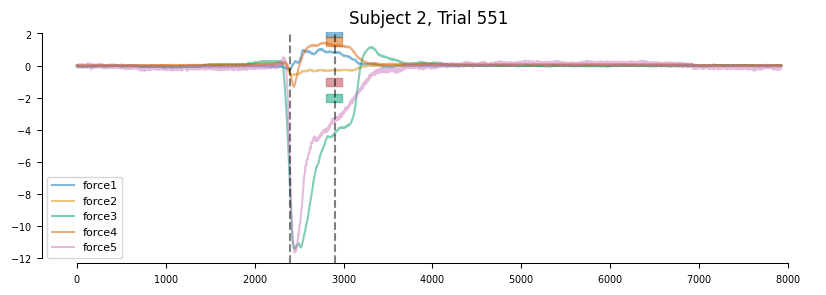

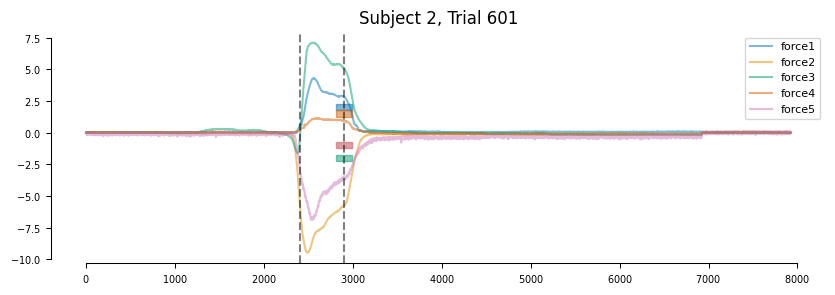

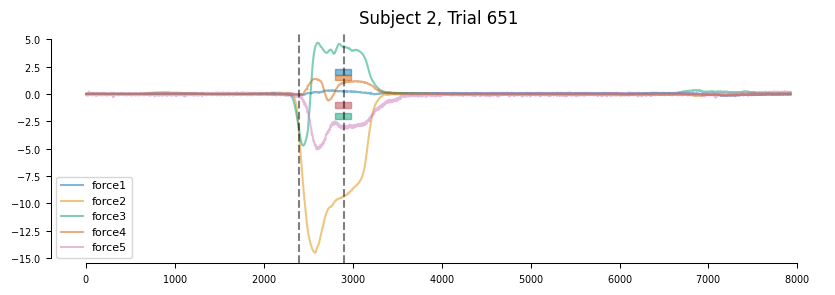

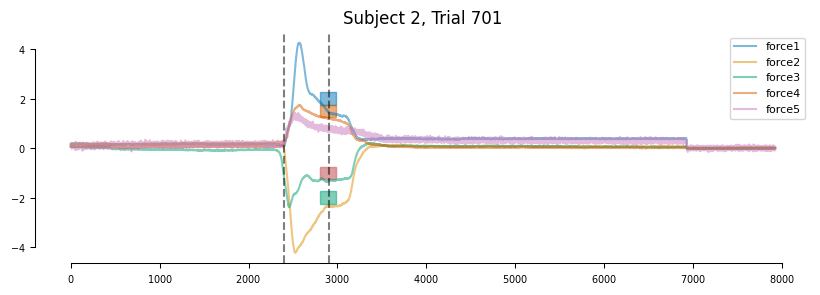

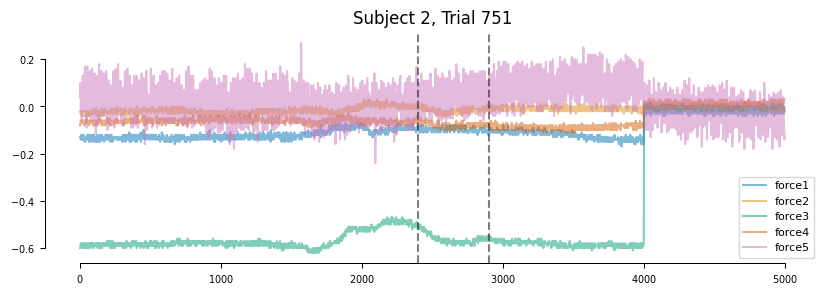

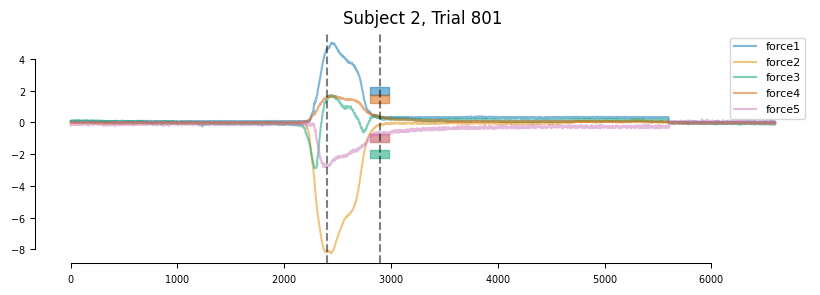

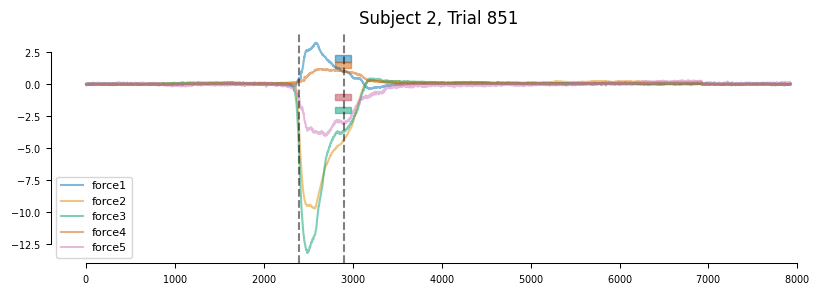

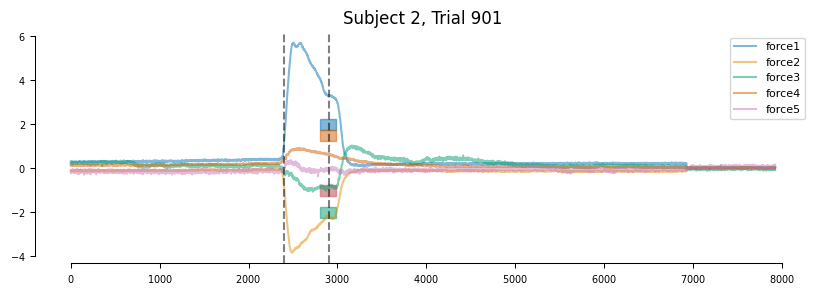

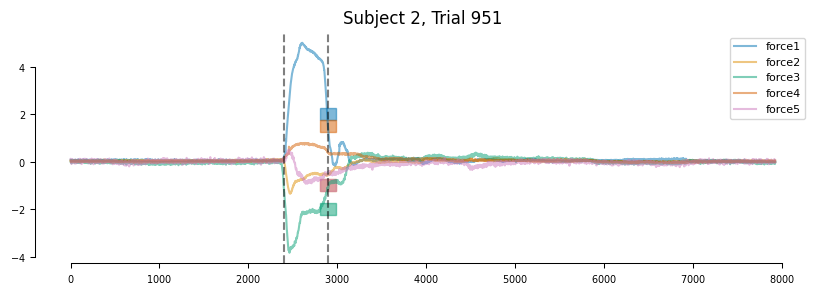

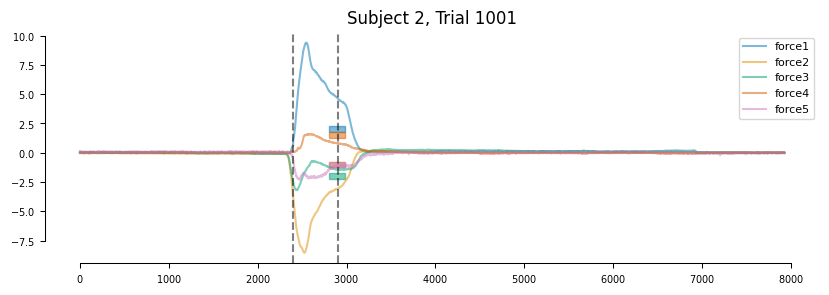

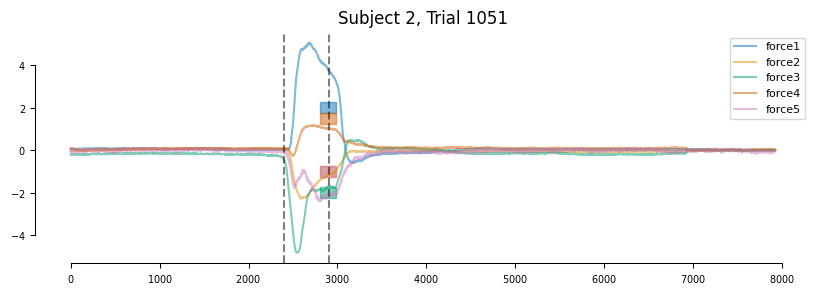

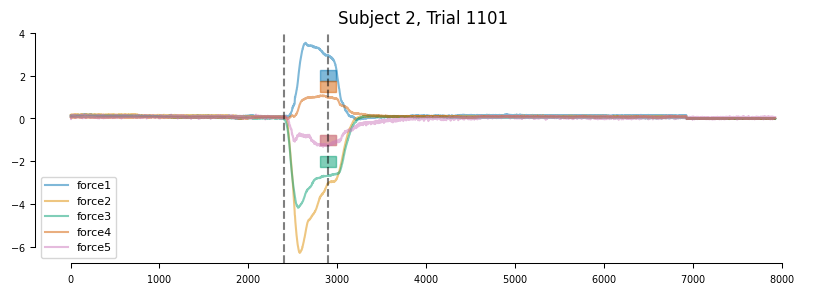

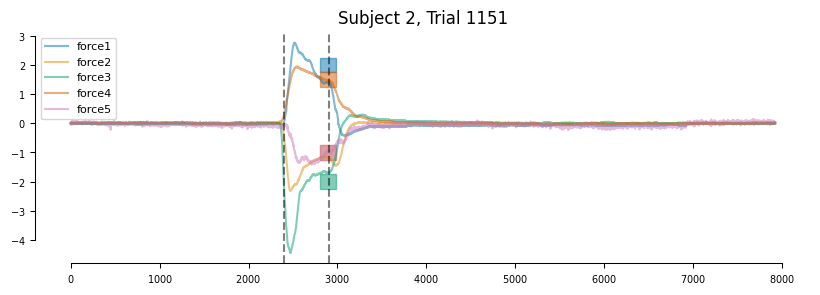

In [10]:
trials_to_plot = list(range(1, num_sessions * num_blocks_per_session * num_trials_per_block + 1, 50))

for trial in trials_to_plot:
    plot_forces(subjs_force_train, sub_num = 2, trial_num = trial)

In [9]:
subjs_force_train.columns

Index(['state', 'time', 'subNum', 'BN', 'TN', 'targetForce1', 'targetForce2',
       'targetForce3', 'targetForce4', 'targetForce5', 'endForce1',
       'endForce2', 'endForce3', 'endForce4', 'endForce5', 'TotalTrialNum',
       'trialPoint', 'trialCorr', 'trialErrorType', 'Force_Number',
       'Force_Value'],
      dtype='object')

In [ ]:
# # fixing end force values from dat files with calculated end force values from forces if the dat file values are missing (nan)

# sub_num = 1
# trial_nums = subjs_force_train[subjs_force_train['subNum'] == sub_num]['TotalTrialNum'].unique()
# for trial_num in trial_nums:
#     x = subjs_force_train[(subjs_force_train['subNum'] == sub_num) & (subjs_force_train['TotalTrialNum'] == trial_num)]

#     for finger in fingers:
#         # calculated from forces (window 25 ms before sampling time to 25 ms after sampling time)
#         window_data = x[(x['time'] >= 2900 - 25) & (x['time'] <= 2900 + 25) & (x['Force_Number'] == f'force{finger}')]
#         mean_force = window_data['Force_Value'].mean()

#         col = f'endForce{finger}'
#         # if dat-file value is missing, fill with calculated mean (only if mean is not NaN)
#         if pd.isna(x[col].iloc[0]) and not np.isnan(mean_force):
#             subjs_force_train.loc[x.index, col] = np.round(mean_force, 3)


In [ ]:
# # fixing end force values from dat files with calculated end force values from forces if the dat file values are missing (nan)

# sub_num = 1
# trial_nums = subjs_force_train[subjs_force_train['subNum'] == sub_num]['TotalTrialNum'].unique()
# for trial_num in trial_nums:
#     x = subjs_force_train[(subjs_force_train['subNum'] == sub_num) & (subjs_force_train['TotalTrialNum'] == trial_num)]

#     points = 0

#     for finger in fingers:
#         finger_force = x[x['Force_Number'] == f'force{finger}']
#         end_point_force = finger_force[f'endForce{finger}'].iloc[0]
#         target_force = finger_force[f'targetForce{finger}'].iloc[0]
#         # print(f"Sub {sub_num}, Trial {trial_num}, Finger {finger}: End Point Force = {end_point_force}, Target Force = {target_force}")
#         points += np.exp(-1 * np.power(end_point_force - target_force, 2))
#     print("Trial:", trial_num)
#     print("Actual Points:", x['trialPoint'].iloc[0])
#     print("Calculated Points:", points)

Trial: 761
Actual Points: 4.216
Calculated Points: 4.216859864817905
Trial: 762
Actual Points: 4.321
Calculated Points: 4.321382461620435
Trial: 763
Actual Points: 4.11
Calculated Points: 4.1093671275868875
Trial: 764
Actual Points: 4.665
Calculated Points: 4.66466402594442
Trial: 765
Actual Points: 4.342
Calculated Points: 4.342241391194255
Trial: 766
Actual Points: 4.841
Calculated Points: 4.841160050856297
Trial: 767
Actual Points: 4.692
Calculated Points: 4.692739586439128
Trial: 768
Actual Points: 4.186
Calculated Points: 4.186493633426853
Trial: 769
Actual Points: 4.538
Calculated Points: 4.537537656287513
Trial: 770
Actual Points: 4.485
Calculated Points: 4.484171261940346
Trial: 771
Actual Points: 4.548
Calculated Points: 4.547393250366615
Trial: 772
Actual Points: 4.206
Calculated Points: 4.206456764323102
Trial: 773
Actual Points: 4.072
Calculated Points: 4.071807622726494
Trial: 774
Actual Points: 4.307
Calculated Points: 4.307561132527457
Trial: 775
Actual Points: 4.747
Cal

In [11]:
subjs_force_train.to_csv(utils.path_misc+'subjs_force_train_exp1.csv', index = False, sep = '\t')
# subjs_force_train = pd.read_csv(utils.path_misc+'subjs_force_train_exp1.csv', sep = '\t')

In [12]:
subjs_force_train

,state,time,subNum,BN,TN,targetForce1,targetForce2,targetForce3,targetForce4,targetForce5,...,endForce2,endForce3,endForce4,endForce5,TotalTrialNum,trialPoint,trialCorr,trialErrorType,Force_Number,Force_Value
0,2.0,0.0,1,39,1,2.0,-1.0,-2.0,1.5,-1.0,...,-1.051,-1.270,1.275,-1.445,761,4.216,1,0,force1,-0.08
1,2.0,2.0,1,39,1,2.0,-1.0,-2.0,1.5,-1.0,...,-1.051,-1.270,1.275,-1.445,761,4.216,1,0,force1,-0.06
2,2.0,4.0,1,39,1,2.0,-1.0,-2.0,1.5,-1.0,...,-1.051,-1.270,1.275,-1.445,761,4.216,1,0,force1,-0.08
3,2.0,6.0,1,39,1,2.0,-1.0,-2.0,1.5,-1.0,...,-1.051,-1.270,1.275,-1.445,761,4.216,1,0,force1,-0.06
4,2.0,8.0,1,39,1,2.0,-1.0,-2.0,1.5,-1.0,...,-1.051,-1.270,1.275,-1.445,761,4.216,1,0,force1,-0.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47027510,6.0,7916.0,1,34,20,2.0,-1.0,-2.0,1.5,-1.0,...,-0.827,-1.586,1.069,-0.876,680,4.628,1,0,force5,-0.01
47027511,6.0,7918.0,1,34,20,2.0,-1.0,-2.0,1.5,-1.0,...,-0.827,-1.586,1.069,-0.876,680,4.628,1,0,force5,0.08
47027512,6.0,7920.0,1,34,20,2.0,-1.0,-2.0,1.5,-1.0,...,-0.827,-1.586,1.069,-0.876,680,4.628,1,0,force5,0.13
47027513,6.0,7922.0,1,34,20,2.0,-1.0,-2.0,1.5,-1.0,...,-0.827,-1.586,1.069,-0.876,680,4.628,1,0,force5,0.09


In [13]:
# smooth forces with a window of 50 ms 
subjs_force_train['Force_Value_Smooth'] = subjs_force_train.groupby(['subNum', 'TotalTrialNum', 'Force_Number'])['Force_Value'].transform(lambda x: x.rolling(window=25, min_periods=1, center=True).mean())

In [14]:
# extract forces between time 2200 ms (before go cue) and 2925 ms (after sampling time)
forces = subjs_force_train[(subjs_force_train['time'] >= 2200) & (subjs_force_train['time'] <= 2925)].copy()

In [116]:
def plot_forces_smooth(subjs_forces, sub_num, trial_num):
    plt.figure(figsize=(8,3))
    x = subjs_forces[(subjs_forces['subNum'] == sub_num) & (subjs_forces['TotalTrialNum'] == trial_num)]
    
    for i, (force, data) in enumerate(x.groupby('Force_Number')):
        plt.plot(data['time'], data['Force_Value_Smooth'], label = force,
                 color = sns.color_palette('colorblind')[i], alpha = 0.5)
    
    
    plt.axvline(2400, color = 'black', linestyle = '--', alpha = 0.5) # go cue 
    plt.axvline(2900, color = 'black', linestyle = '--', alpha = 0.5) # sampling time


    target_cols = [f"targetForce{finger}" for finger in fingers]
    target_vals = x[target_cols].iloc[0].to_numpy(dtype=float)


    ax = plt.gca()

    rec_height = 0.5
    for finger in fingers:
        ax.add_patch(Rectangle((2900 - 25, target_vals[int(finger)-1]- (rec_height/2)), 
                            50, rec_height, color = sns.color_palette('colorblind')[int(finger)-1],alpha=0.5))


    plt.title(f'Subject {sub_num}, Trial {trial_num}')
    plt.ylim(-3, 3)
    plt.legend()
    sns.despine(trim = True)

    plt.show()
    

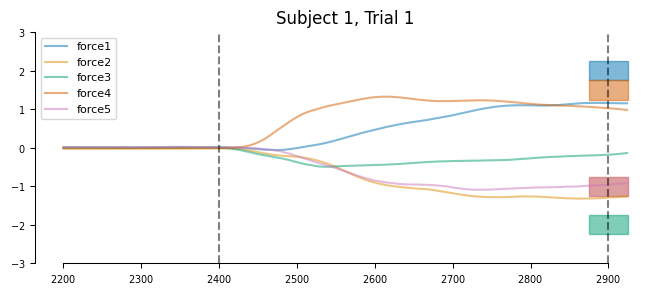

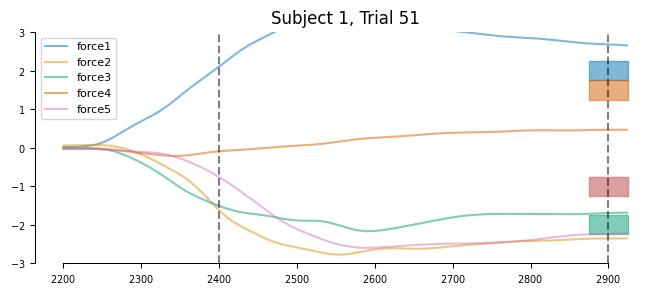

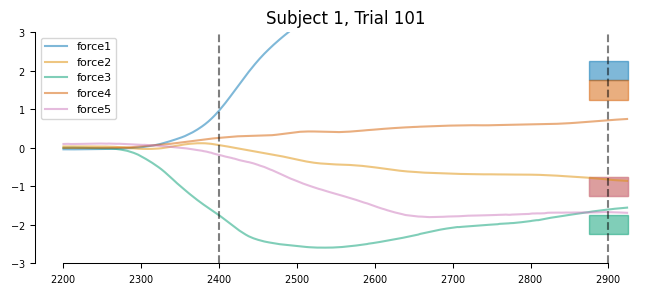

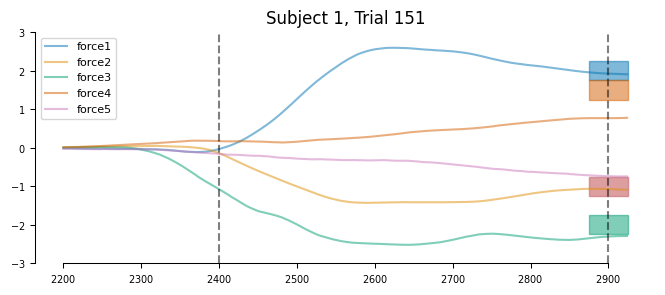

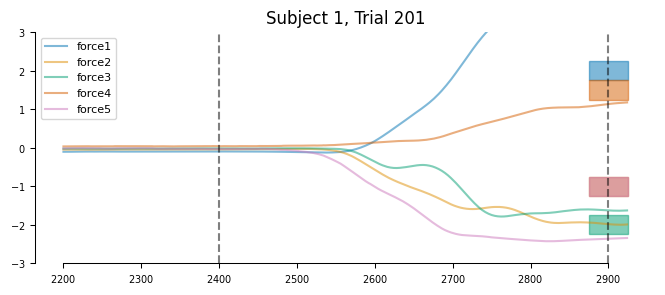

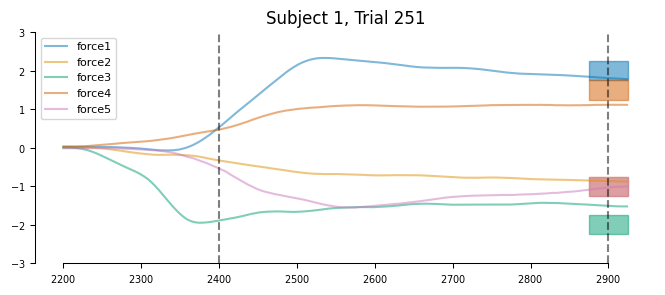

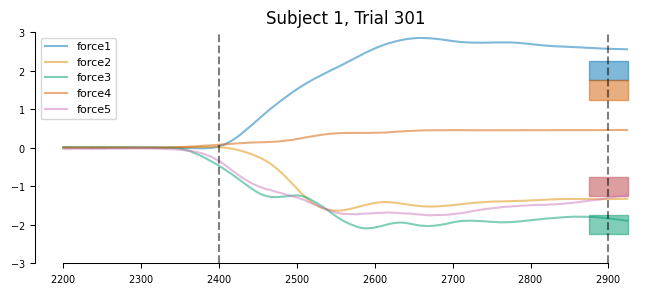

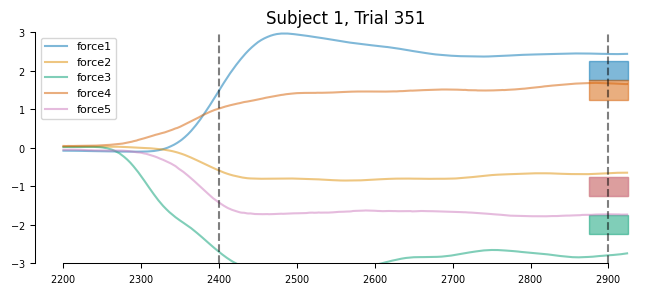

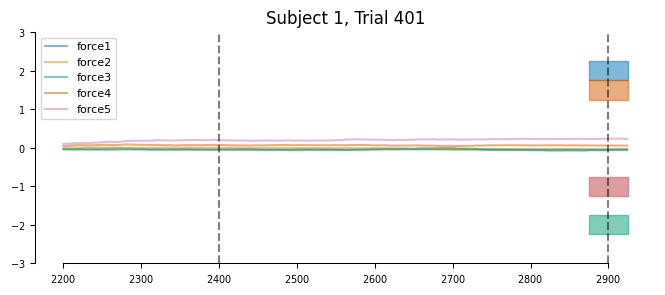

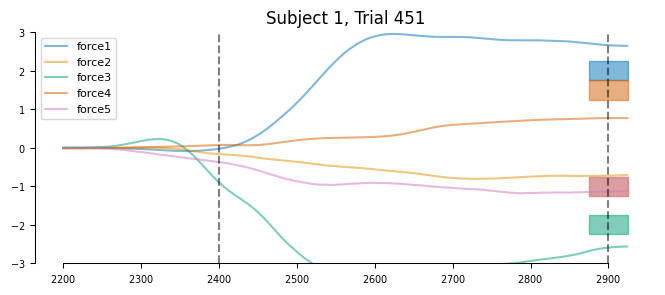

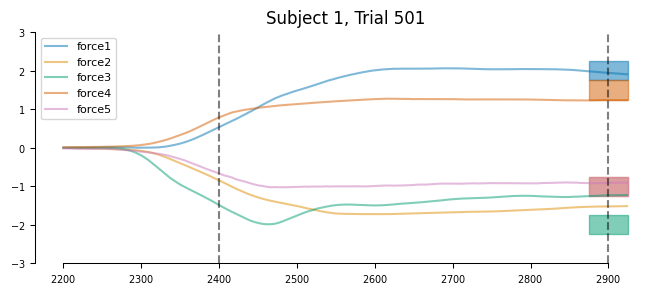

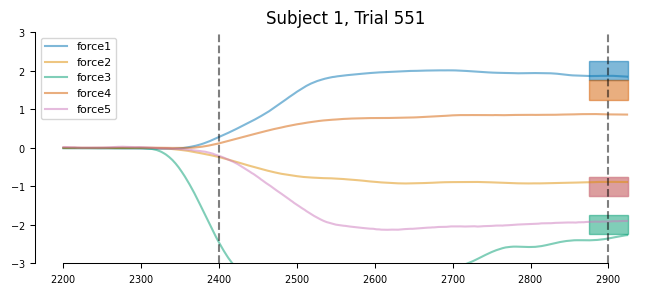

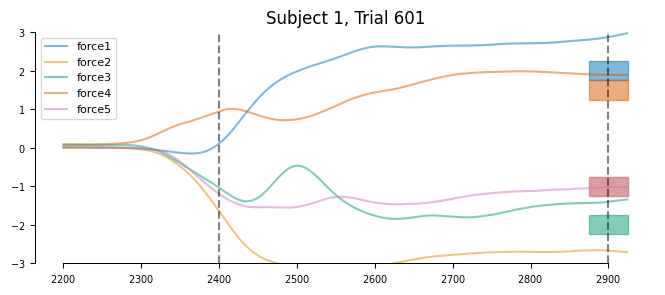

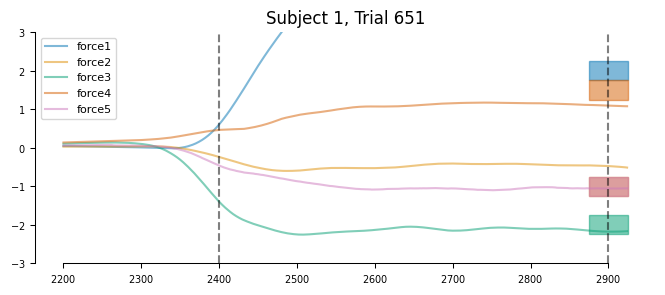

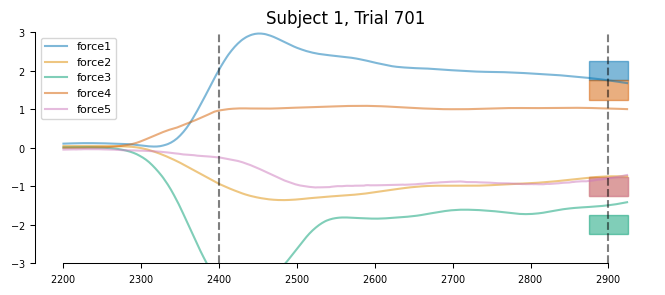

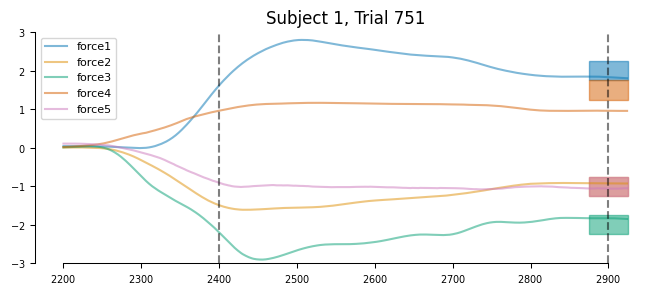

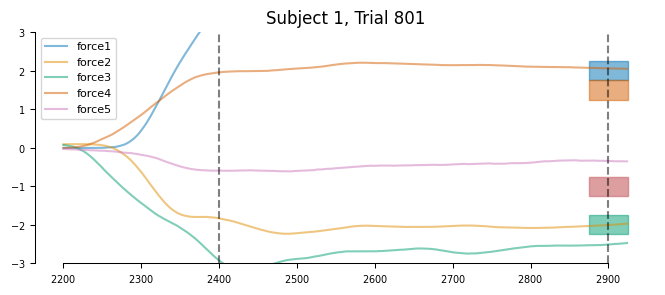

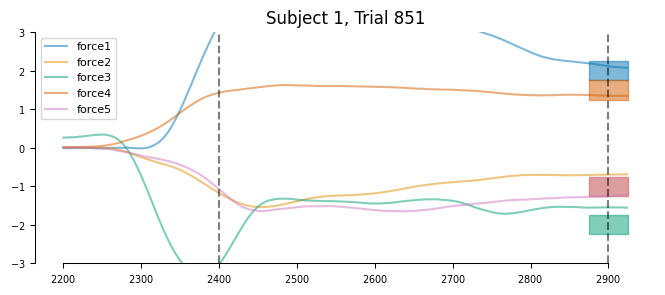

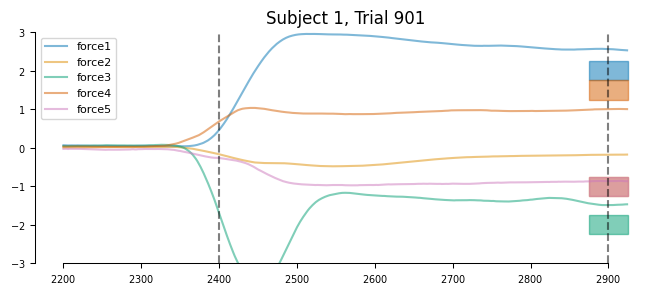

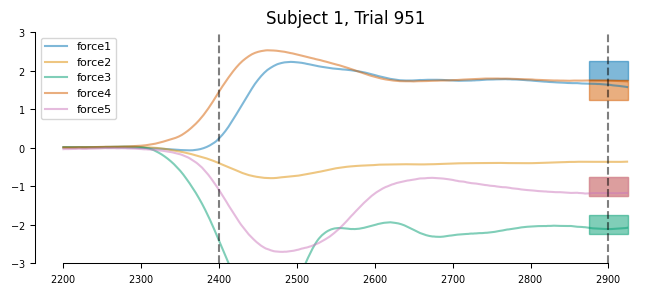

In [117]:
trials_to_plot = list(range(1, num_sessions * num_blocks_per_session * num_trials_per_block + 1, 50))

for trial in trials_to_plot:
    plot_forces_smooth(forces, sub_num = 1, trial_num = trial)

In [15]:
def plot_forces_smooth_average(subjs_forces, sub_num):
    x = subjs_forces[subjs_forces['subNum'] == sub_num].copy()
    x = utils.remove_error_trials(x)
    target_cols = [f"targetForce{finger}" for finger in fingers]
    target_vals = x[target_cols].iloc[0].to_numpy(dtype=float)
    
    # bucket forces into 100 trial bins 
    x['trial_bin'] = pd.cut(x['TotalTrialNum'], bins=np.arange(0, x['TotalTrialNum'].max() + 100, 100), labels=False)
    avg_forces = x.groupby(['trial_bin', 'Force_Number', 'time'])['Force_Value_Smooth'].mean().reset_index()
    
    for trial_bin, trial_bin_data in avg_forces.groupby('trial_bin'):
        plt.figure(figsize=(3,3))
        for i, (force, data) in enumerate(trial_bin_data.groupby('Force_Number')):
            plt.plot(data['time'], data['Force_Value_Smooth'], label = f'{force}',
                     color = sns.color_palette('colorblind')[i], alpha = 0.5)
            
        plt.axvline(2400, color = 'black', linestyle = '--', alpha = 0.5) # go cue
        plt.axvline(2900, color = 'black', linestyle = '--', alpha = 0.5) # sampling time

        rec_height = 0.5

        ax = plt.gca()
        for finger in fingers:
            ax.add_patch(Rectangle((2900 - 25, target_vals[int(finger)-1]- (rec_height/2)), 
                                50, rec_height, color = sns.color_palette('colorblind')[int(finger)-1],alpha=0.5))

        plt.title(f'Subject {sub_num}, Trials {trial_bin*100} - {(trial_bin+1)*100}')
        plt.ylim(-5, 5)
        # plt.legend()
        sns.despine(trim = True)
        plt.savefig(f'{path_figs}subjs_forces/sub{sub_num}_trials_{trial_bin*100}_{(trial_bin+1)*100}_avg_forces.pdf', dpi = 300, bbox_inches='tight')
        plt.show()
        


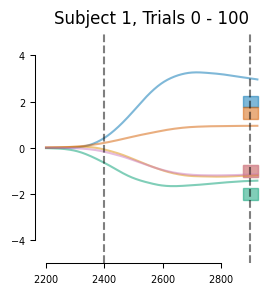

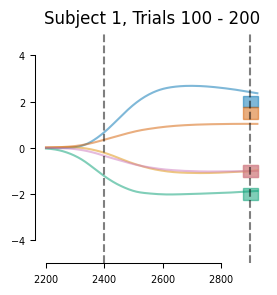

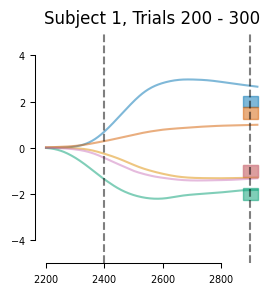

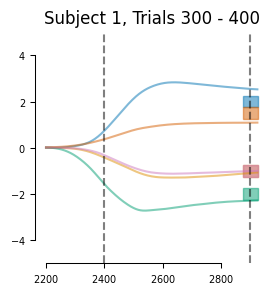

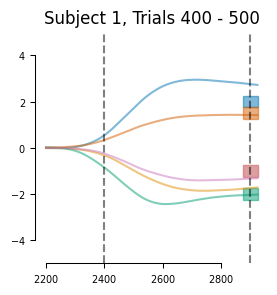

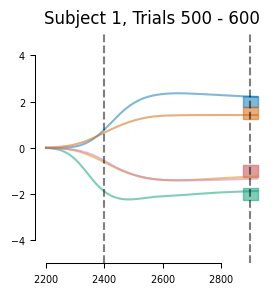

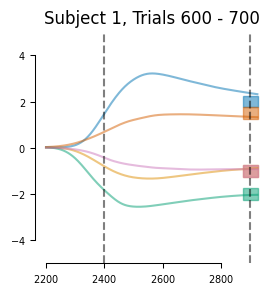

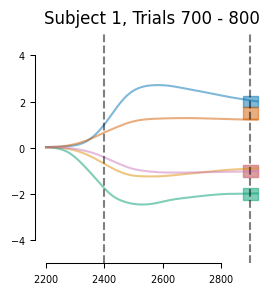

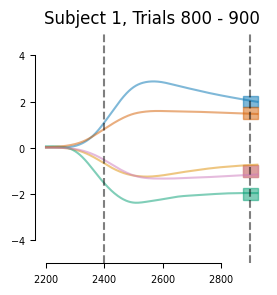

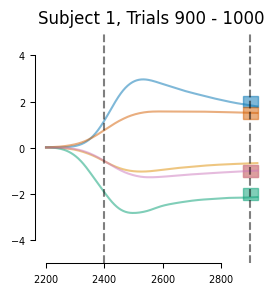

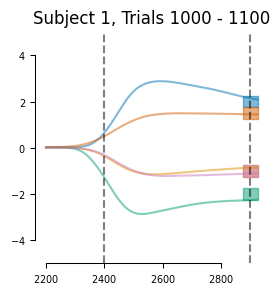

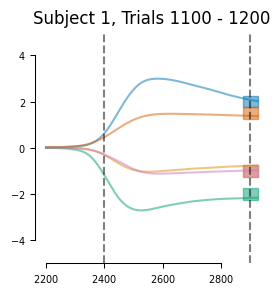

In [17]:
avg_forces = plot_forces_smooth_average(forces, sub_num = 1)

In [131]:
avg_forces

,trial_bin,Force_Number,time,Force_Value_Smooth
0,0,force1,2200.0,-0.009073
1,0,force1,2202.0,-0.008996
2,0,force1,2204.0,-0.009024
3,0,force1,2206.0,-0.009029
4,0,force1,2208.0,-0.009118
...,...,...,...,...
18145,9,force5,2916.0,-0.992429
18146,9,force5,2918.0,-0.991347
18147,9,force5,2920.0,-0.990396
18148,9,force5,2922.0,-0.989290


In [18]:
forces_wide = forces.pivot_table(index=[
    'subNum', 'BN' , 'TN', 'targetForce1', 'targetForce2', 'targetForce3', 'targetForce4', 'targetForce5',
    'endForce1', 'endForce2', 'endForce3', 'endForce4', 'endForce5',
    'TotalTrialNum', 'trialPoint', 'trialCorr', 'trialErrorType'], columns = ['Force_Number', 'time'], 
    values = 'Force_Value_Smooth').reset_index()


In [19]:
# convert MultiIndex columns to single level
forces_wide.columns = [''.join(map(str, col)).strip() for col in forces_wide.columns.values]
force_cols = [col for col in forces_wide.columns if col.startswith('force')]
new_names = {old: f'force_{i+1}' for i, old in enumerate(force_cols)}
forces_wide.rename(columns=new_names, inplace=True)
forces_wide.to_csv(utils.path_misc+'forces_wide.csv', index = False)

In [111]:
forces_wide.columns

Index(['subNum', 'BN', 'TN', 'targetForce1', 'targetForce2', 'targetForce3',
       'targetForce4', 'targetForce5', 'endForce1', 'endForce2',
       ...
       'force_1806', 'force_1807', 'force_1808', 'force_1809', 'force_1810',
       'force_1811', 'force_1812', 'force_1813', 'force_1814', 'force_1815'],
      dtype='object', length=1832)